# Lab 4 — Assignment


**Based on:** Lab-4-b (Bernoulli, Binomial, Poisson, Normal, Uniform)


---

### Instructions

1. Run the **Setup** cell first. Do not modify it.
2. There are **10 questions** — two on each distribution. Attempt **all** of them.
3. Every question has three parts:
   - **(a)** and **(b)** — work these out **by hand** and type your working in the *Written answer* cell.
   - **(c)** — write **Python code** in the blank code cell provided and produce the plot asked for.
4. Use `DISCRETE_COLOR` for discrete plots (bars) and `CONTINUOUS_COLOR` for continuous plots (curves).
5. Every plot must have an **x-label, y-label and a title**. Marks are deducted for unlabelled plots.
6. Round all probabilities to **4 decimal places**.
7. Save the notebook with all outputs visible before submitting.

### Marks distribution

| Section | Questions | Marks each | Total |
|---|---|---|---|
| A — Bernoulli | Q1, Q2 | 5 | 10 |
| B — Binomial | Q3, Q4 | 5 | 10 |
| C — Poisson | Q5, Q6 | 5 | 10 |
| D — Normal | Q7, Q8 | 5 | 10 |
| E — Uniform | Q9, Q10 | 5 | 10 |
| | | **Total** | **50** |

### Quick reference — which function do I need?

| Task | `scipy.stats` call |
|---|---|
| $P(X = k)$, discrete | `.pmf(k, ...)` |
| $f(x)$, continuous | `.pdf(x, ...)` |
| $P(X \le x)$ | `.cdf(x, ...)` |
| $P(X > x)$ | `.sf(x, ...)` |
| Value with given $P(X \le x)$ | `.ppf(prob, ...)` |
| Mean / variance | `.mean(...)`, `.var(...)` |
| Random samples | `.rvs(..., size=n, random_state=seed)` |

---

## Setup
Run this cell first — do not change it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from math import comb, factorial, exp, sqrt

DISCRETE_COLOR = "#0E9F9A"     # teal   -> discrete distributions
CONTINUOUS_COLOR = "#E4572E"   # orange -> continuous distributions
HIGHLIGHT_COLOR = "#F4A261"    # use this to highlight a bar or a shaded area

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Setup complete — you are ready to start.")

Setup complete — you are ready to start.


---
# Part A — Bernoulli distribution
*Recall:* $P(X=x) = p^x(1-p)^{1-x}$ for $x \in \{0,1\}$, $\;E[X]=p$, $\;Var(X)=p(1-p)$.

## Q1. The library gate scanner 

> 📚 The RFID gate at the college library reads a student's ID card correctly on the **first tap 92%** of the time. One student taps her card once.
>
> Let $X = 1$ if the card is read on the first tap, and $X = 0$ if it is not.
>
> **(a)** State the value of $p$ and find $P(X=1)$ and $P(X=0)$.
> **(b)** Find the mean and the variance of $X$, showing the substitution into the formulas.
> **(c)** Write Python code that:
> - builds the PMF of $X$ using `stats.bernoulli.pmf`,
> - draws a **bar chart** of the distribution in `DISCRETE_COLOR` with the ticks labelled `"Not read (0)"` and `"Read (1)"`,
> - writes the probability value on top of each bar,
> - prints the mean and the variance obtained from `scipy`, and checks that they match your hand answers in (b).

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

**(a)** The probability of success is $p = 0.92$. So

$$P(X=1) = p = 0.92, \qquad P(X=0) = 1-p = 1-0.92 = 0.08$$

**(b)** Substituting $p = 0.92$:

$$E[X] = p = 0.92$$

$$Var(X) = p(1-p) = 0.92 \times 0.08 = 0.0736$$


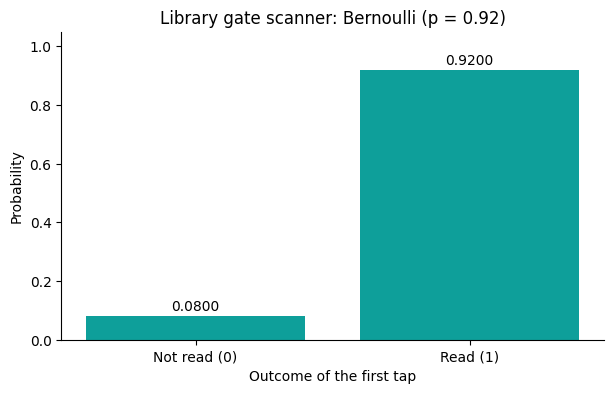

Mean = 0.92
Variance = 0.0736
Matches hand answer: True


In [2]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
x=[0,1]
p=.92
pmf=stats.bernoulli.pmf(x,p)
plt.bar(x,pmf,color=DISCRETE_COLOR)
for i in x:
    plt.text(i,pmf[i]+0.02,f"{pmf[i]:.4f}",ha="center")
plt.xticks(x,["Not read (0)","Read (1)"])
plt.xlabel("Outcome of the first tap")
plt.ylabel("Probability")
plt.title("Library gate scanner: Bernoulli (p = 0.92)")
plt.ylim(0,1.05)
plt.show()

mean=stats.bernoulli.mean(p)
var=stats.bernoulli.var(p)
print("Mean =",round(mean,4))
print("Variance =",round(var,4))
print("Matches hand answer:",np.isclose(mean,0.92) and np.isclose(var,0.92*0.08))
# ------------------------------------------------------------

## Q2. Estimating $p$ from attendance data &nbsp;&nbsp;<sub>[5 marks] — *harder*</sub>

> 👆 A biometric attendance device records whether a student's fingerprint is accepted on the **first attempt**. Over one semester the device logged **2,000 scans**, of which **1,740** were accepted on the first attempt. Treat one scan as a single Bernoulli trial with $X=1$ for *accepted*.
>
> **(a)** Estimate $p$ from the data and write down the full PMF $P(X=x)$ with the estimated value substituted in.
> **(b)** Find the mean and variance. Then answer: for what value of $p$ would the variance of a Bernoulli variable be the **largest possible**, and what is that largest value? Justify your answer using the formula $Var(X)=p(1-p)$.
> **(c)** Write Python code that:
> - simulates 2,000 Bernoulli trials with your estimated $p$ using `stats.bernoulli.rvs(..., random_state=42)`,
> - prints the **simulated proportion** of successes next to the theoretical $p$,
> - plots the **theoretical PMF and the simulated relative frequencies side by side** as grouped bars with a legend,
> - plots $Var(X)=p(1-p)$ against $p$ for $p$ from 0 to 1 in a **second figure**, and marks the maximum point with a marker and an annotation.

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

**(a)** Estimate $p$ by the observed proportion of successes:

$$\hat p = \frac{1740}{2000} = 0.87$$

$$P(X=x) = 0.87^{\,x}\,(0.13)^{1-x}, \qquad x \in \{0,1\}$$

so $P(X=1) = 0.87$ and $P(X=0) = 0.13$.

**(b)** $E[X] = p = 0.87$ and $Var(X) = p(1-p) = 0.87 \times 0.13 = 0.1131$.

*Largest possible variance.* $Var(X) = p(1-p) = p - p^2$.

$$\frac{d}{dp}(p-p^2) = 1-2p = 0 \;\Rightarrow\; p = 0.5, \qquad \frac{d^2}{dp^2}(p-p^2) = -2 < 0 \;\Rightarrow\; \text{a maximum}$$

Equivalently, $p(1-p) = \dfrac14 - \left(p-\dfrac12\right)^2 \le \dfrac14$, with equality only at $p=\dfrac12$.

$$Var_{\max} = 0.5 \times 0.5 = 0.25 \quad \text{at } p = 0.5$$

A fair coin (outcome hardest to predict) has the largest variance; as $p \to 0$ or $p \to 1$ the outcome becomes certain and the variance shrinks to 0.


Theoretical p = 0.87
Simulated proportion = 0.8675
Mean = 0.87 Variance = 0.1131


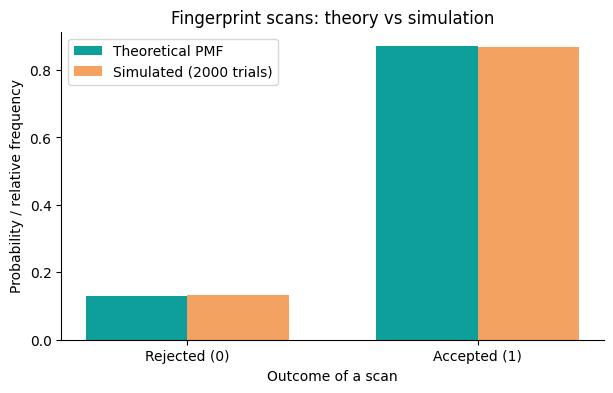

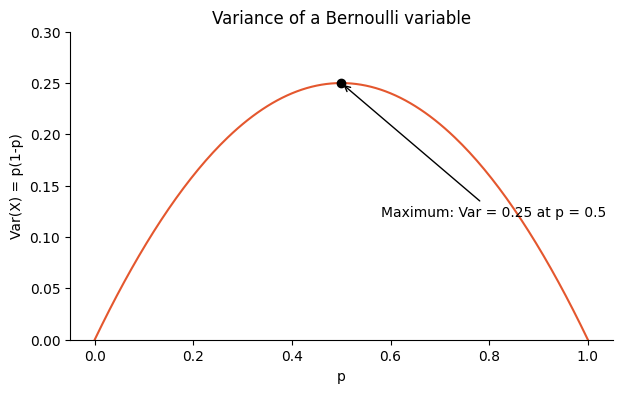

In [3]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
p=1740/2000
x=np.array([0,1])
theory=stats.bernoulli.pmf(x,p)
sample=stats.bernoulli.rvs(p,size=2000,random_state=42)
sim=np.bincount(sample,minlength=2)/len(sample)
print("Theoretical p =",round(p,4))
print("Simulated proportion =",round(sample.mean(),4))
print("Mean =",round(stats.bernoulli.mean(p),4),"Variance =",round(stats.bernoulli.var(p),4))

w=0.35
plt.bar(x-w/2,theory,w,color=DISCRETE_COLOR,label="Theoretical PMF")
plt.bar(x+w/2,sim,w,color=HIGHLIGHT_COLOR,label="Simulated (2000 trials)")
plt.xticks(x,["Rejected (0)","Accepted (1)"])
plt.xlabel("Outcome of a scan")
plt.ylabel("Probability / relative frequency")
plt.title("Fingerprint scans: theory vs simulation")
plt.legend()
plt.show()

pp=np.linspace(0,1,201)
var=pp*(1-pp)
imax=np.argmax(var)
plt.plot(pp,var,color=CONTINUOUS_COLOR)
plt.plot(pp[imax],var[imax],"o",color="black")
plt.annotate(f"Maximum: Var = {var[imax]:.2f} at p = {pp[imax]:.1f}",xy=(pp[imax],var[imax]),xytext=(0.58,0.12),arrowprops=dict(arrowstyle="->"))
plt.ylim(0,0.3)
plt.xlabel("p")
plt.ylabel("Var(X) = p(1-p)")
plt.title("Variance of a Bernoulli variable")
plt.show()
# ------------------------------------------------------------

---
# Part B — Binomial distribution
*Recall:* $P(X=k) = \binom{n}{k}p^k(1-p)^{n-k}$, $\;E[X]=np$, $\;Var(X)=np(1-p)$.

## Q3. Guessing a multiple-choice quiz &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 📝 An online quiz has **12 multiple-choice questions**, each with **4 options** and exactly one correct answer. A student who has not studied guesses every answer at random. Let $X$ = number of questions answered correctly.
>
> **(a)** State $n$ and $p$, check that the **BINS** conditions hold, and compute $P(X=5)$ **by hand**, showing the value of $\binom{12}{5}$.
> **(b)** Find the mean and the variance of $X$.
> **(c)** Write Python code that:
> - plots the PMF as a bar chart for $k = 0$ to $12$ in `DISCRETE_COLOR`,
>

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

**(a)** $n = 12$ and $p = \dfrac14 = 0.25$.

BINS check:
- **B**inary: each question is either correct or wrong ✔
- **I**ndependent: guessing one question does not affect another ✔
- **N**umber of trials is fixed: $n = 12$ ✔
- **S**ame probability: every question has 4 options, so $p = 0.25$ each time ✔

$$\binom{12}{5} = \frac{12!}{5!\,7!} = \frac{12\times11\times10\times9\times8}{5\times4\times3\times2\times1} = \frac{95040}{120} = 792$$

$$P(X=5) = \binom{12}{5}(0.25)^5(0.75)^7 = 792 \times 0.000977 \times 0.1335 \approx 0.1032$$

**(b)** $E[X] = np = 12 \times 0.25 = 3$ and $Var(X) = np(1-p) = 3 \times 0.75 = 2.25$.


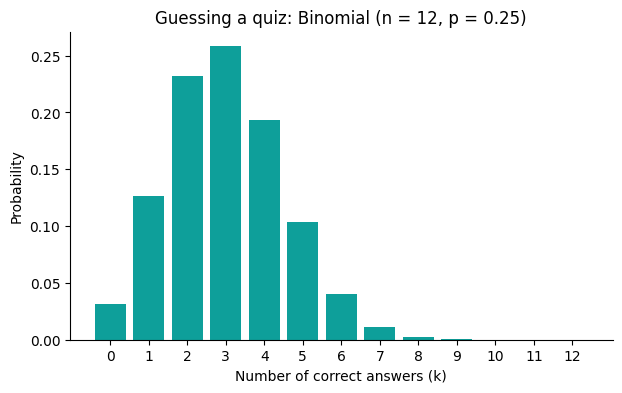

P(X=5) = 0.1032
Mean = 3.0 Variance = 2.25


In [4]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
n=12
p=.25
k=np.arange(0,n+1)
pmf=stats.binom.pmf(k,n,p)
plt.bar(k,pmf,color=DISCRETE_COLOR)
plt.xticks(k)
plt.xlabel("Number of correct answers (k)")
plt.ylabel("Probability")
plt.title("Guessing a quiz: Binomial (n = 12, p = 0.25)")
plt.show()
print("P(X=5) =",round(stats.binom.pmf(5,n,p),4))
print("Mean =",stats.binom.mean(n,p),"Variance =",stats.binom.var(n,p))
# ------------------------------------------------------------

#### ✍️ Written answer (a), (b) and (d) — *type your hand calculation below*

> 
> 
> 
> 
> 


---
# Part C — Poisson distribution
*Recall:* $P(X=k) = \dfrac{\lambda^k e^{-\lambda}}{k!}$, $\;E[X]=Var(X)=\lambda$.

## Q5. Help-desk emails &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 📧 The IT help-desk of a college receives on average **3 emails per hour**. Let $X$ = number of emails received in one hour.
>
> **(a)** Compute $P(X = 0)$ and $P(X = 2)$ **by hand**, showing the substitution into the formula ($e^{-3} \approx 0.0498$).
> **(b)** State the mean and the variance, and explain in one line what is special about them for a Poisson distribution.
> **(c)** Write Python code that:
> - plots the PMF as a bar chart for $k = 0$ to $12$ in `DISCRETE_COLOR`,
> - prints $P(X=0)$, $P(X=2)$ and $P(X \le 5)$,
> - prints the smallest value of $k$ for which $P(X \le k) \ge 0.95$ (use `.ppf` or a loop).

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

**(a)** Here $\lambda = 3$.

$$P(X=0) = \frac{3^0 e^{-3}}{0!} = e^{-3} \approx 0.0498$$

$$P(X=2) = \frac{3^2 e^{-3}}{2!} = \frac{9 \times 0.0498}{2} \approx 0.2241$$

(Python gives $0.2240$; the small difference is only because $e^{-3}$ was rounded to $0.0498$ by hand.)

**(b)** $E[X] = \lambda = 3$ and $Var(X) = \lambda = 3$.

⭐ Special property: for a Poisson distribution the **mean equals the variance** (both are $\lambda$).


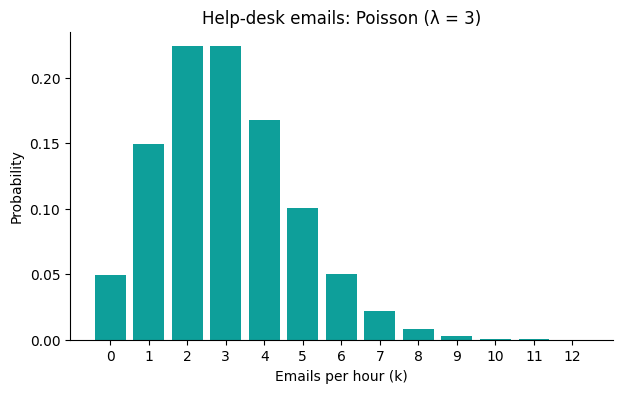

P(X=0) = 0.0498
P(X=2) = 0.224
P(X<=5) = 0.9161
Smallest k with P(X<=k) >= 0.95: 6


In [5]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
la=3
n=12
k=np.arange(0,n+1)
pmf=stats.poisson.pmf(k,la)
plt.bar(k,pmf,color=DISCRETE_COLOR)
plt.xticks(k)
plt.xlabel("Emails per hour (k)")
plt.ylabel("Probability")
plt.title("Help-desk emails: Poisson (λ = 3)")
plt.show()
print("P(X=0) =",round(stats.poisson.pmf(0,la),4))
print("P(X=2) =",round(stats.poisson.pmf(2,la),4))
print("P(X<=5) =",round(stats.poisson.cdf(5,la),4))
print("Smallest k with P(X<=k) >= 0.95:",int(stats.poisson.ppf(0.95,la)))
# ------------------------------------------------------------

## Q6. Server errors over a night shift &nbsp;&nbsp;<sub>[5 marks] — *harder*</sub>

> 🖥️ A web server logs errors at an average rate of **1.5 errors per hour**. The night shift runs from 10 pm to 6 am, i.e. **8 hours**.
>
> **(a)** Find the value of $\lambda$ for the **whole 8-hour shift**, and compute by hand the probability of a **clean shift** (zero errors in the 8 hours).
> **(b)** State the mean and variance for the 8-hour window. The on-call engineer is paged if **more than 18 errors** occur in the shift — write the expression for that probability and name the `scipy` function that gives it directly.
> **(c)** Write Python code that:
> - creates **two subplots side by side** — the PMF for the 1-hour window ($\lambda = 1.5$) and the PMF for the 8-hour window — each with its own sensible range of $k$, title and labels,


#### ✍️ Written answer (a), (b) and (d) — *type your hand calculation below*

**(a)** The rate scales with the length of the interval, so for 8 hours:

$$\lambda = 1.5 \times 8 = 12$$

$$P(X=0) = \frac{12^0 e^{-12}}{0!} = e^{-12} \approx 6.14 \times 10^{-6} \approx 0.0000$$

A completely clean 8-hour shift is practically impossible.

**(b)** $E[X] = \lambda = 12$ and $Var(X) = \lambda = 12$.

The engineer is paged when **more than 18** errors occur, i.e. $X \ge 19$:

$$P(X>18) = 1 - P(X \le 18) = 1 - \sum_{k=0}^{18}\frac{12^k e^{-12}}{k!}$$

The `scipy` function that gives this directly is the survival function `stats.poisson.sf(18, 12)`, which is $1 - \text{cdf}(18)$. Its value is $\approx 0.0374$.


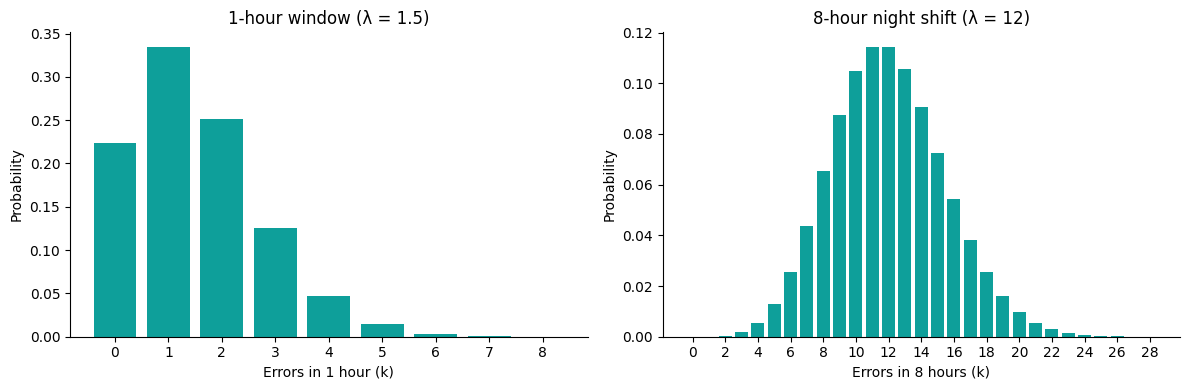

lambda (8 hours) = 12.0
P(X=0) = 0.0000  (= 6.14e-06)
P(X>18) = 0.0374


In [6]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
la1=1.5
la8=1.5*8
k1=np.arange(0,9)
k8=np.arange(0,29)

fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].bar(k1,stats.poisson.pmf(k1,la1),color=DISCRETE_COLOR)
ax[0].set_xticks(k1)
ax[0].set_xlabel("Errors in 1 hour (k)")
ax[0].set_ylabel("Probability")
ax[0].set_title("1-hour window (λ = 1.5)")
ax[1].bar(k8,stats.poisson.pmf(k8,la8),color=DISCRETE_COLOR)
ax[1].set_xticks(k8[::2])
ax[1].set_xlabel("Errors in 8 hours (k)")
ax[1].set_ylabel("Probability")
ax[1].set_title("8-hour night shift (λ = 12)")
plt.tight_layout()
plt.show()

p0=stats.poisson.pmf(0,la8)
print("lambda (8 hours) =",la8)
print(f"P(X=0) = {p0:.4f}  (= {p0:.2e})")
print("P(X>18) =",round(stats.poisson.sf(18,la8),4))
# ------------------------------------------------------------

---
# Part D — Normal distribution
*Recall:* $f(x)=\dfrac{1}{\sigma\sqrt{2\pi}}e^{-(x-\mu)^2/2\sigma^2}$, $\;Z=\dfrac{X-\mu}{\sigma}$, $\;E[X]=\mu$, $\;Var(X)=\sigma^2$.

## Q7. Battery life of a phone &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 🔋 The battery life of a phone model is normally distributed with a mean of **18 hours** and a standard deviation of **1.5 hours**. Let $X$ = battery life of a randomly chosen phone.
>
> **(a)** Compute the **Z-score** for a battery life of 15 hours and say in words what that Z-score means.
> **(b)** Using the 68–95–99.7 rule, state the interval of battery lives that contains about **95%** of the phones. Show how you obtained it.
> **(c)** Write Python code that:
> - generates 400 equally spaced values of $x$ over $\mu \pm 4\sigma$ and computes the PDF,
> - plots the curve in `CONTINUOUS_COLOR` with a title and axis labels,
.

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

**(a)** Here $\mu = 18$ and $\sigma = 1.5$.

$$Z = \frac{X-\mu}{\sigma} = \frac{15-18}{1.5} = \frac{-3}{1.5} = -2$$

A $Z$-score of $-2$ means a battery life of 15 hours is **2 standard deviations below the mean**, so it is unusually short.

**(b)** By the 68–95–99.7 rule, about 95% of values lie within $\mu \pm 2\sigma$:

$$18 \pm 2(1.5) = 18 \pm 3 \;\Rightarrow\; [15,\ 21] \text{ hours}$$

So about 95% of the phones last between **15 and 21 hours**.


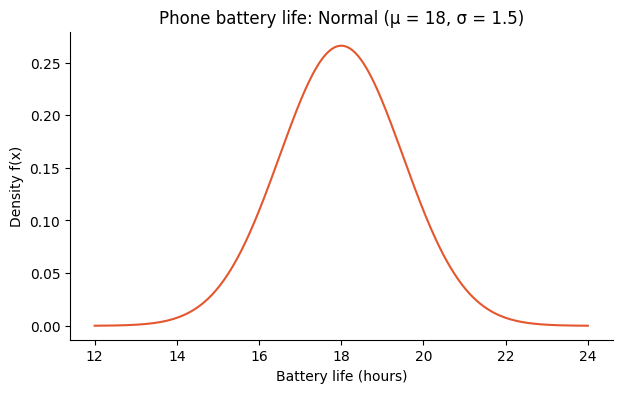

Z-score for 15 hours = -2.0


In [7]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
mu=18
sigma=1.5
x=np.linspace(mu-4*sigma,mu+4*sigma,400)
pdf=stats.norm.pdf(x,mu,sigma)
plt.plot(x,pdf,color=CONTINUOUS_COLOR)
plt.xlabel("Battery life (hours)")
plt.ylabel("Density f(x)")
plt.title("Phone battery life: Normal (μ = 18, σ = 1.5)")
plt.show()
print("Z-score for 15 hours =",(15-mu)/sigma)
# ------------------------------------------------------------

## Q8. Calibrating a coffee machine &nbsp;&nbsp;<sub>[5 marks] — *harder*</sub>

> ☕ A vending machine fills cups with coffee. The fill volume is normally distributed with a mean of **200 ml**, but the standard deviation is **not known**. The service log shows that **2.5% of cups overflow**, which happens whenever the fill exceeds **210 ml**.
>
> **(a)** Using the standard normal value $z_{0.975} \approx 1.96$, find the standard deviation $\sigma$ of the fill volume. Show the working.
> **(b)** With that $\sigma$, find the volume below which only **1%** of cups fall (the 1st percentile), and state which `scipy` function gives it. A customer complains if the cup holds less than **190 ml** — write the expression for that probability.
> **(c)** Write Python code that:
> - computes $\sigma$ using `stats.norm.ppf` rather than the rounded 1.96,
> - plots the PDF over a sensible range in `CONTINUOUS_COLOR`,



#### ✍️ Written answer (a), (b) and (d) — *type your hand calculation below*

**(a)** Overflow happens when $X > 210$ and $P(X>210) = 0.025$, so $P(X \le 210) = 0.975$. Therefore the $Z$-score of 210 ml is $z_{0.975} \approx 1.96$:

$$\frac{210-200}{\sigma} = 1.96 \;\Rightarrow\; \sigma = \frac{10}{1.96} \approx 5.10 \text{ ml}$$

**(b)** For the 1st percentile we need the $z$-value with $P(Z \le z) = 0.01$, which is $z_{0.01} \approx -2.326$:

$$x_{0.01} = \mu + z_{0.01}\,\sigma = 200 + (-2.326)(5.10) \approx 188.13 \text{ ml}$$

So only 1% of cups hold less than about **188.13 ml**. The `scipy` function that gives this is the inverse CDF (percent-point function): `stats.norm.ppf(0.01, loc=200, scale=sigma)`.

A customer complains if the cup holds less than 190 ml:

$$P(X<190) = \Phi\!\left(\frac{190-200}{\sigma}\right) = \Phi(-1.96) = 0.025$$

In Python: `stats.norm.cdf(190, loc=200, scale=sigma)`. It equals the overflow probability because 190 ml is exactly as far below the mean as 210 ml is above it (the normal curve is symmetric).


z = 1.96
sigma = 5.1021 ml


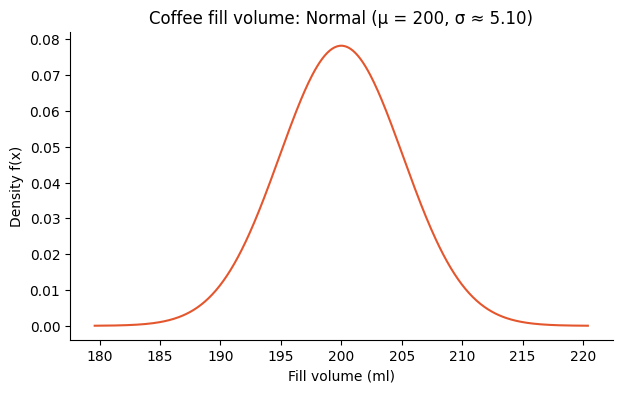

In [8]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
mu=200
z=stats.norm.ppf(.975)
sigma=(210-mu)/z
print("z =",round(z,4))
print("sigma =",round(sigma,4),"ml")

x=np.linspace(mu-4*sigma,mu+4*sigma,400)
pdf=stats.norm.pdf(x,mu,sigma)
plt.plot(x,pdf,color=CONTINUOUS_COLOR)
plt.xlabel("Fill volume (ml)")
plt.ylabel("Density f(x)")
plt.title("Coffee fill volume: Normal (μ = 200, σ ≈ 5.10)")
plt.show()

print("1st percentile =",round(stats.norm.ppf(.01,mu,sigma),4),"ml")
print("P(X<190) =",round(stats.norm.cdf(190,mu,sigma),4))
# ------------------------------------------------------------

---
# Part E — Uniform distribution
*Recall:* $f(x)=\dfrac{1}{b-a}$ for $a \le x \le b$, $\;P(c \le X \le d)=\dfrac{d-c}{b-a}$, $\;E[X]=\dfrac{a+b}{2}$, $\;Var(X)=\dfrac{(b-a)^2}{12}$.

⚠️ **Note on `scipy`:** for a uniform distribution on $[a, b]$ you must use `loc=a` and `scale=b-a`, **not** `loc=a, scale=b`.

## Q9. Waiting for the campus shuttle &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 🚌 The campus shuttle leaves the gate exactly every **15 minutes**. A student walks up to the stop at a completely random moment, so her waiting time $X$ is uniformly distributed between **0 and 15 minutes**.
>

> **(a)** Find the mean waiting time and the variance, showing the substitution.
> **(b)** Write Python code that:
> - plots the PDF as a flat line/rectangle over $[0, 15]$ in `CONTINUOUS_COLOR` (extend the x-axis a little beyond the range so the flat top is clear),


#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

**(a)** Here $a = 0$ and $b = 15$.

$$E[X] = \frac{a+b}{2} = \frac{0+15}{2} = 7.5 \text{ minutes}$$

$$Var(X) = \frac{(b-a)^2}{12} = \frac{15^2}{12} = \frac{225}{12} = 18.75 \text{ minutes}^2$$

The height of the flat PDF is $\dfrac{1}{b-a} = \dfrac{1}{15} \approx 0.0667$.

**(b)** See the code cell below.


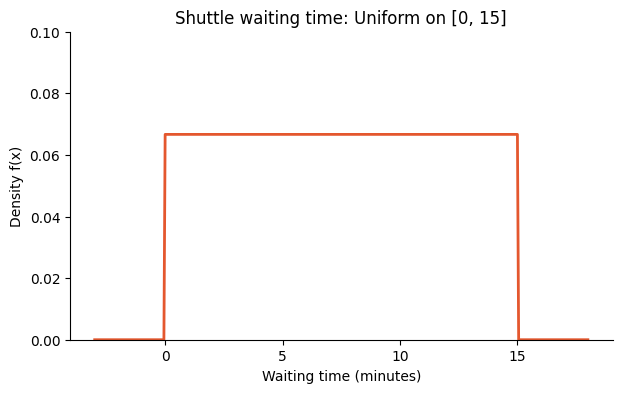

Mean = 7.5
Variance = 18.75


In [9]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
a=0
b=15
x=np.linspace(a-3,b+3,400)
pdf=stats.uniform.pdf(x,loc=a,scale=b-a)
plt.plot(x,pdf,color=CONTINUOUS_COLOR,lw=2)
plt.ylim(0,0.1)
plt.xlabel("Waiting time (minutes)")
plt.ylabel("Density f(x)")
plt.title("Shuttle waiting time: Uniform on [0, 15]")
plt.show()
print("Mean =",stats.uniform.mean(loc=a,scale=b-a))
print("Variance =",stats.uniform.var(loc=a,scale=b-a))
# ------------------------------------------------------------